D:\conda\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Welcome to salary prediction system
Press ENTER KEY to proceed

0 ... Salary_Prediction.csv
select file to create ML Model0
Salary_Prediction.csv is selected
Reading csv file
Creating Dataset
Dataset Created
Enter test data size (between 0 to 1)0.2
Model created in progression
Model is created
Press ENTER key to predict test data in trained model

[[ 3.2]
 [10.5]
 [ 3. ]
 [ 8.7]
 [ 4. ]
 [ 9. ]]   ... [ 54445 121872  60150 109431  56957 105582]   ... [ 56029.87736092 126541.92230135  54098.04051324 109155.3906722
  63757.22475165 112053.14594372]
[3.2] ... 54445 ... 56029.877360919905
[10.5] ... 121872 ... 126541.92230134597
[3.] ... 60150 ... 54098.040513237
[8.7] ... 109431 ... 109155.3906721998
[4.] ... 56957 ... 63757.22475165153
[9.] ... 105582 ... 112053.14594372417
press ENTER key to see above graphical format



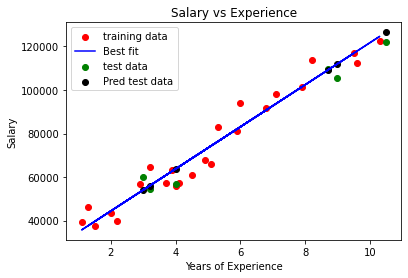

our model is 96.84% accurate
Now you can predict salary of an employee using our model

Enter experience in years of the candidates, seperated by comma
5,7.9


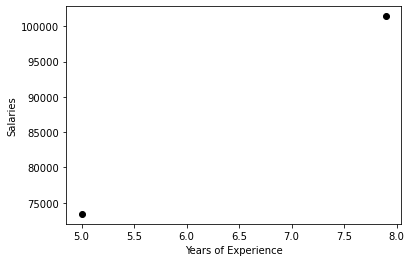

   Experience       Salaries
0         5.0   73416.408990
1         7.9  101428.043281



In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score#

def welcome():
    print("Welcome to salary prediction system")
    print("Press ENTER KEY to proceed")
    input()

def checkcsv():
    csv_files = []
    cur_dir = os.getcwd()
    content_list = os.listdir(cur_dir)
    for x in content_list:
        if x.split(".")[-1] == 'csv':
            csv_files.append(x)
        
    if len(csv_files) == 0:
        return "No CSV files in the directory"
    else:
        return csv_files


def display_and_select_csv (csv_files):
    i = 0
    for file_name in csv_files:
        print(i,"...", file_name)
        i +=1
    return csv_files[int(input("select file to create ML Model" ))]#

def graph(X_train, Y_train, regressionObject, X_test, Y_test, Y_pred):#
    plt.scatter(X_train, Y_train, color = "red", label= "training data")#
    plt.plot(X_train, regressionObject.predict(X_train), color = "blue", label = "Best fit")#
    plt.scatter(X_test, Y_test, color = "green", label = "test data")#
    plt.scatter(X_test, Y_pred, color = "black", label = "Pred test data")#
    plt.title("Salary vs Experience")#
    plt.xlabel("Years of Experience")#
    plt.ylabel("Salary")#
    plt.legend()#
    plt.show()#

def main():
    welcome()
    try:
        csv_files = checkcsv()
        if csv_files == "No csv files in the directory":
            raise FileNotFoundError("No csv files in the directory")
        csv_files = display_and_select_csv(csv_files)
        print(csv_files, "is selected")
        print("Reading csv file")
        print("Creating Dataset")
        dataset = pd.read_csv(csv_files)
        print("Dataset Created")
        X = dataset.iloc[:,:-1].values
        Y = dataset.iloc[:,-1].values
        s = float(input("Enter test data size (between 0 to 1)"))
        X_train,X_test,Y_train, Y_test = train_test_split(X, Y, test_size=s)
        print("Model created in progression")
        regressionObject = LinearRegression()
        regressionObject.fit(X_train, Y_train)
        print("Model is created")
        print("Press ENTER key to predict test data in trained model")
        input()
        
        
        
        Y_pred = regressionObject.predict(X_test)
        i = 0 #
        print(X_test, "  ...", Y_test, "  ...", Y_pred)#
        while i<len(X_test): #
            print(X_test[i], "...", Y_test[i], "...", Y_pred[i])#
            i+=1 #
        print("press ENTER key to see above graphical format")#
        input()#
        graph(X_train, Y_train, regressionObject, X_test, Y_test, Y_pred)#
        r2 = r2_score(Y_test, Y_pred)#
        print("our model is %2.2f%% accurate" %(r2*100))#
        print("Now you can predict salary of an employee using our model")#
        print("\nEnter experience in years of the candidates, seperated by comma")#
            
            
        exp = [float(e) for e in input().split(",")]#
        ex = []#
        for x in exp: #
            ex.append([x])#
        experience = np.array(ex)#
        salaries = regressionObject.predict(experience)#
            
        plt.scatter(experience, salaries, color = "black")#
        plt.xlabel("Years of Experience")#
        plt.ylabel("Salaries")#
        plt.show()#
            
        d = pd.DataFrame({"Experience":exp, "Salaries":salaries})#
        print(d)#
            
            
    except FileNotFoundError:
        print("No csv file in the directory")
        print("Press ENTER key to exit")#
        input()#
        exit()#
            
if __name__ == "__main__":
    main()
    input()

